In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

In [2]:
base_dir = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"

metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_dir, "HAM10000_images_part_2")

print("Metadata exists:", os.path.exists(metadata_path))
print("Image dir 1 exists:", os.path.exists(image_dir_1))
print("Image dir 2 exists:", os.path.exists(image_dir_2))

Metadata exists: True
Image dir 1 exists: True
Image dir 2 exists: True


In [3]:
df = pd.read_csv(metadata_path)
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
def get_image_path(image_id):
    file_name = image_id + ".jpg"

    path1 = os.path.join(image_dir_1, file_name)
    path2 = os.path.join(image_dir_2, file_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["image_path"]).copy()

print("Remaining rows:", len(df))

Remaining rows: 10015


In [5]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
df["label_num"] = df["binary_label"].map({"benign": 0, "malignant": 1})

print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [6]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_num"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7010
Validation size: 1502
Test size: 1503


In [7]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_num"]),
    y=train_df["label_num"]
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


In [8]:
IMG_SIZE = 260
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [10]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 260, 260,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [11]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnet_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [12]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5130 - loss: 1.0504
Epoch 1: val_loss improved from None to 0.69667, saving model to efficientnet_stage1_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 115s 512ms/step - accuracy: 0.5020 - loss: 1.0122 - val_accuracy: 0.1957 - val_loss: 0.6967 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.4899 - loss: 0.8499
Epoch 2: val_loss did not improve from 0.69667
220/220 ━━━━━━━━━━━━━━━━━━━━ 108s 491ms/step - accuracy: 0.4892 - loss: 0.8253 - val_accuracy: 0.1957 - val_loss: 0.6988 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.5176 - loss: 0.7711
Epoch 3: val_loss improved from 0.69667 to 0.69161, saving model to efficientnet_stage1_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 110s 499ms/step - accuracy: 0.5185 - loss: 0.7504 - val_accuracy: 0.6185 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - acc

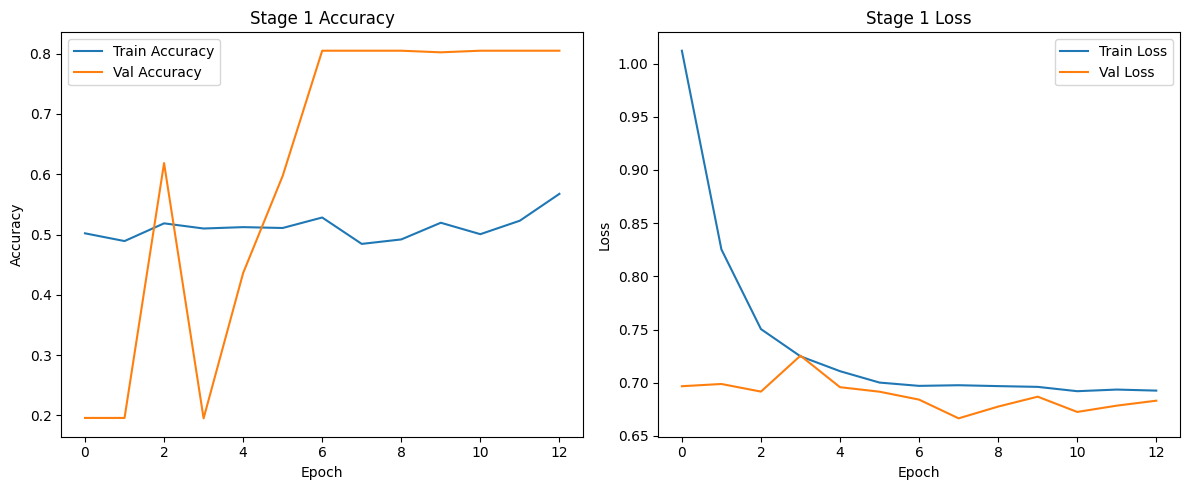

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_stage1.history["accuracy"], label="Train Accuracy")
plt.plot(history_stage1.history["val_accuracy"], label="Val Accuracy")
plt.title("Stage 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_stage1.history["loss"], label="Train Loss")
plt.plot(history_stage1.history["val_loss"], label="Val Loss")
plt.title("Stage 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 446ms/step
Accuracy: 0.8051

Classification Report:

              precision    recall  f1-score   support

      Benign       0.81      1.00      0.89      1210
   Malignant       0.00      0.00      0.00       293

    accuracy                           0.81      1503
   macro avg       0.40      0.50      0.45      1503
weighted avg       0.65      0.81      0.72      1503



/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/melanodetect/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

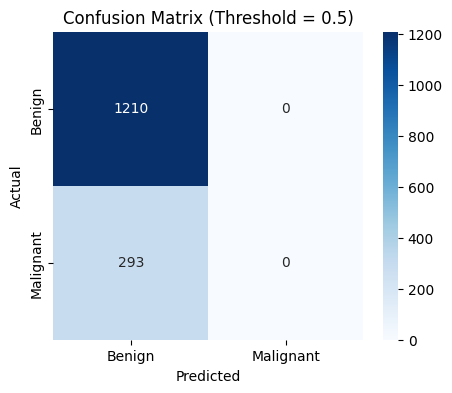

In [14]:
y_probs = model.predict(test_generator).flatten()
y_true = test_df["label_num"].values

threshold = 0.50
y_pred = (y_probs > threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", round(acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
IMG_SIZE = 260
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [16]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [17]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 260, 260,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 260, 260,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 260, 260,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [18]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnet_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [19]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7053 - loss: 0.6647
Epoch 1: val_loss improved from None to 0.43436, saving model to efficientnet_stage1_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 119s 527ms/step - accuracy: 0.7235 - loss: 0.5991 - val_accuracy: 0.7783 - val_loss: 0.4344 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7499 - loss: 0.4961
Epoch 2: val_loss did not improve from 0.43436
220/220 ━━━━━━━━━━━━━━━━━━━━ 113s 513ms/step - accuracy: 0.7492 - loss: 0.4823 - val_accuracy: 0.7636 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7488 - loss: 0.4591
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.43436
220/220 ━━━━━━━━━━━━━━━━━━━━ 106s 480ms/step - accuracy: 0.7561 - loss: 0.4473 - val_accuracy: 0.7230 - val_loss: 0.5797 - learning_rate: 0.0010
Epoch 4/15
220/220 ━━━━━━━━━━━━━━━

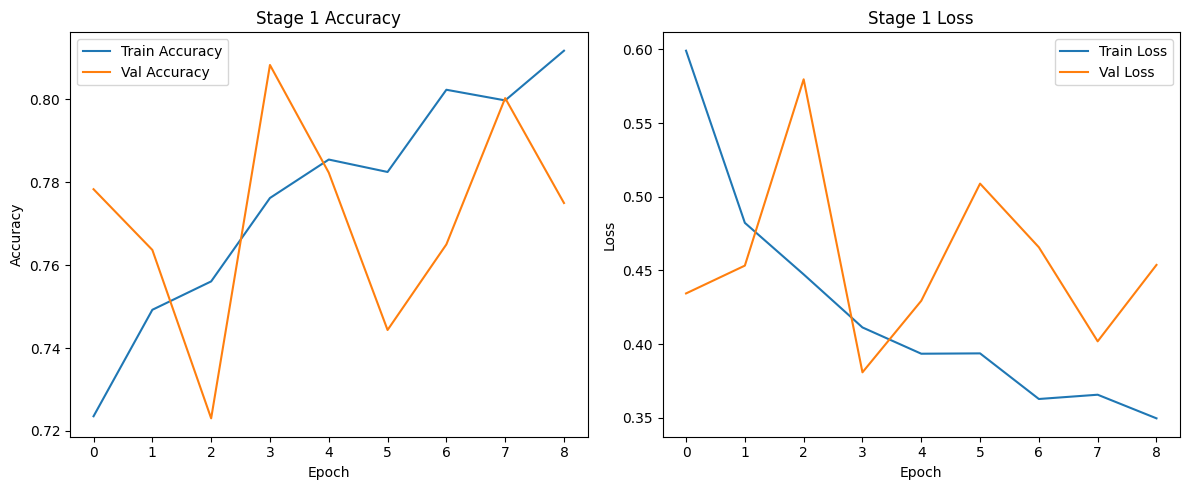

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_stage1.history["accuracy"], label="Train Accuracy")
plt.plot(history_stage1.history["val_accuracy"], label="Val Accuracy")
plt.title("Stage 1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_stage1.history["loss"], label="Train Loss")
plt.plot(history_stage1.history["val_loss"], label="Val Loss")
plt.title("Stage 1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 482ms/step
Accuracy: 0.8283

Classification Report:

              precision    recall  f1-score   support

      Benign       0.93      0.85      0.89      1210
   Malignant       0.54      0.75      0.63       293

    accuracy                           0.83      1503
   macro avg       0.74      0.80      0.76      1503
weighted avg       0.86      0.83      0.84      1503



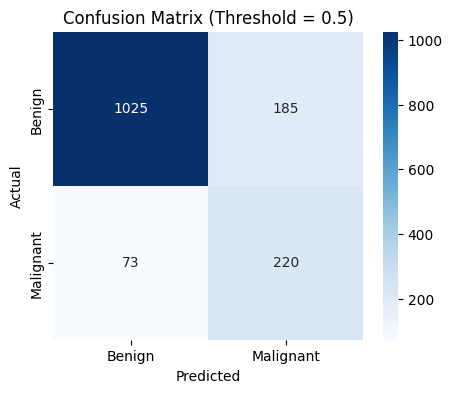

In [21]:
y_probs = model.predict(test_generator).flatten()
y_true = test_df["label_num"].values

threshold = 0.50
y_pred = (y_probs > threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", round(acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# Unfreeze top layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # VERY SMALL LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 260, 260,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 260, 260,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 260, 260,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 2,857,617 (10.90 MB)

 Non-trainable params: 1,525,267 (5.82 MB)

In [23]:
history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7359 - loss: 0.5037
Epoch 1: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 145s 639ms/step - accuracy: 0.7402 - loss: 0.4824 - val_accuracy: 0.7756 - val_loss: 0.4462 - learning_rate: 1.0000e-05
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.7552 - loss: 0.4534
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 139s 629ms/step - accuracy: 0.7538 - loss: 0.4312 - val_accuracy: 0.7617 - val_loss: 0.4735 - learning_rate: 1.0000e-05
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.7556 - loss: 0.4378
Epoch 3: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 145s 656ms/step - accuracy: 0.7572 - loss: 0.4308 - val_accuracy: 0.7563 - val_loss: 0.4831 - learning_rate: 5.0000e-06
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.742

In [25]:
from tensorflow.keras.models import load_model

In [28]:
model = load_model("efficientnet_stage1_best.keras")
print("Stage 1 best model loaded successfully")

Stage 1 best model loaded successfully


In [30]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer))

0 input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'>
1 rescaling_2 <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
2 normalization_1 <class 'keras.src.layers.preprocessing.normalization.Normalization'>
3 rescaling_3 <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
4 stem_conv_pad <class 'keras.src.layers.reshaping.zero_padding2d.ZeroPadding2D'>
5 stem_conv <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
6 stem_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
7 stem_activation <class 'keras.src.layers.activations.activation.Activation'>
8 block1a_dwconv <class 'keras.src.layers.convolutional.depthwise_conv2d.DepthwiseConv2D'>
9 block1a_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
10 block1a_activation <class 'keras.src.layers.activations.activation.Activation'>
11 block1a_se_squeeze <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
12

In [31]:
base_model = model.layers[1]

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

print("Base model selected:", base_model.name)
print("Total layers in base model:", len(base_model.layers))

AttributeError: 'Rescaling' object has no attribute 'layers'

In [32]:
for i, layer in enumerate(model.layers[:10]):
    print(i, layer.name, type(layer))

0 input_layer_1 <class 'keras.src.layers.core.input_layer.InputLayer'>
1 rescaling_2 <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
2 normalization_1 <class 'keras.src.layers.preprocessing.normalization.Normalization'>
3 rescaling_3 <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>
4 stem_conv_pad <class 'keras.src.layers.reshaping.zero_padding2d.ZeroPadding2D'>
5 stem_conv <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
6 stem_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
7 stem_activation <class 'keras.src.layers.activations.activation.Activation'>
8 block1a_dwconv <class 'keras.src.layers.convolutional.depthwise_conv2d.DepthwiseConv2D'>
9 block1a_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>


In [33]:
for layer in model.layers:
    layer.trainable = False

In [34]:
for layer in model.layers[-20:]:
    layer.trainable = True

In [35]:
for i, layer in enumerate(model.layers[-25:]):
    print(i + len(model.layers) - 25, layer.name, layer.trainable)

218 block6d_project_conv False
219 block6d_project_bn False
220 block6d_drop False
221 block6d_add False
222 block7a_expand_conv False
223 block7a_expand_bn True
224 block7a_expand_activation True
225 block7a_dwconv True
226 block7a_bn True
227 block7a_activation True
228 block7a_se_squeeze True
229 block7a_se_reshape True
230 block7a_se_reduce True
231 block7a_se_expand True
232 block7a_se_excite True
233 block7a_project_conv True
234 block7a_project_bn True
235 top_conv True
236 top_bn True
237 top_activation True
238 global_average_pooling2d_1 True
239 batch_normalization_1 True
240 dense_2 True
241 dropout_1 True
242 dense_3 True


In [36]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [37]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 260, 260,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 260, 260,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 260, 260,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 1,238,961 (4.73 MB)

 Non-trainable params: 3,143,923 (11.99 MB)

In [38]:
history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/6
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.7494 - loss: 0.5007
Epoch 1: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 130s 578ms/step - accuracy: 0.7535 - loss: 0.4805 - val_accuracy: 0.7850 - val_loss: 0.4029 - learning_rate: 5.0000e-06
Epoch 2/6
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.7688 - loss: 0.4321
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 2: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 132s 599ms/step - accuracy: 0.7578 - loss: 0.4401 - val_accuracy: 0.7756 - val_loss: 0.4293 - learning_rate: 5.0000e-06
Epoch 3/6
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.7560 - loss: 0.4329
Epoch 3: val_loss did not improve from 0.38081
220/220 ━━━━━━━━━━━━━━━━━━━━ 116s 525ms/step - accuracy: 0.7578 - loss: 0.4402 - val_accuracy: 0.7783 - val_loss: 0.4363 - learning_rate: 2.5000e-06
Epoch 4/6
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.7562 - 

In [39]:
from tensorflow.keras.models import load_model

final_stage1_model = load_model("efficientnet_stage1_best.keras")
print("Stage 1 best model loaded")

Stage 1 best model loaded


In [40]:
y_probs = final_stage1_model.predict(test_generator).flatten()
y_true = test_df["label_num"].values

print("Predictions shape:", y_probs.shape)
print("First 10 probabilities:", y_probs[:10])

47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 411ms/step
Predictions shape: (1503,)
First 10 probabilities: [9.5283486e-02 6.4377898e-01 8.5719132e-01 8.2186496e-01 1.4345656e-05
 2.1678165e-02 6.7218847e-05 4.3978912e-04 5.1361915e-02 2.3971391e-01]



========== Threshold = 0.5 ==========
Accuracy: 0.8283
              precision    recall  f1-score   support

      Benign       0.93      0.85      0.89      1210
   Malignant       0.54      0.75      0.63       293

    accuracy                           0.83      1503
   macro avg       0.74      0.80      0.76      1503
weighted avg       0.86      0.83      0.84      1503



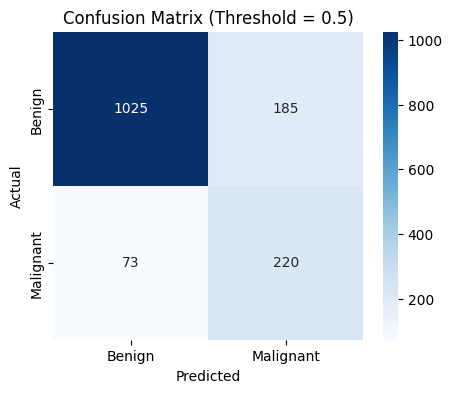


========== Threshold = 0.45 ==========
Accuracy: 0.8077
              precision    recall  f1-score   support

      Benign       0.94      0.82      0.87      1210
   Malignant       0.50      0.77      0.61       293

    accuracy                           0.81      1503
   macro avg       0.72      0.80      0.74      1503
weighted avg       0.85      0.81      0.82      1503



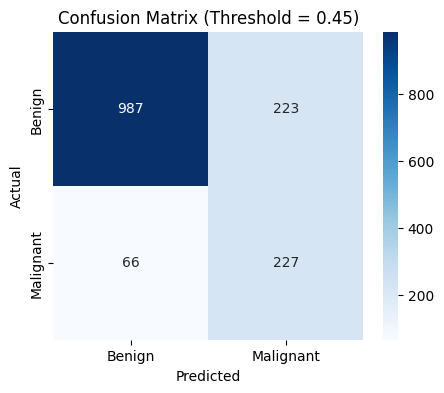


========== Threshold = 0.4 ==========
Accuracy: 0.7891
              precision    recall  f1-score   support

      Benign       0.94      0.79      0.86      1210
   Malignant       0.48      0.80      0.60       293

    accuracy                           0.79      1503
   macro avg       0.71      0.79      0.73      1503
weighted avg       0.85      0.79      0.81      1503



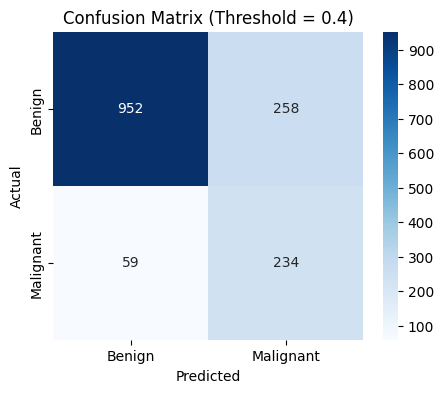


========== Threshold = 0.35 ==========
Accuracy: 0.7778
              precision    recall  f1-score   support

      Benign       0.95      0.76      0.85      1210
   Malignant       0.46      0.84      0.59       293

    accuracy                           0.78      1503
   macro avg       0.71      0.80      0.72      1503
weighted avg       0.86      0.78      0.80      1503



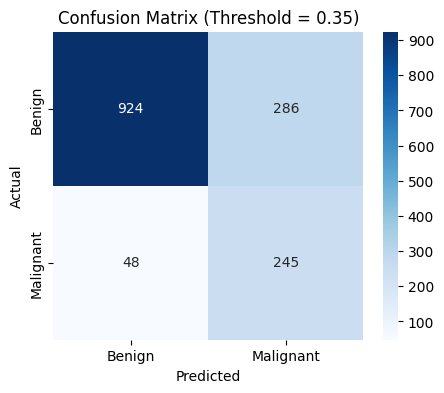


========== Threshold = 0.3 ==========
Accuracy: 0.7618
              precision    recall  f1-score   support

      Benign       0.96      0.73      0.83      1210
   Malignant       0.44      0.88      0.59       293

    accuracy                           0.76      1503
   macro avg       0.70      0.81      0.71      1503
weighted avg       0.86      0.76      0.78      1503



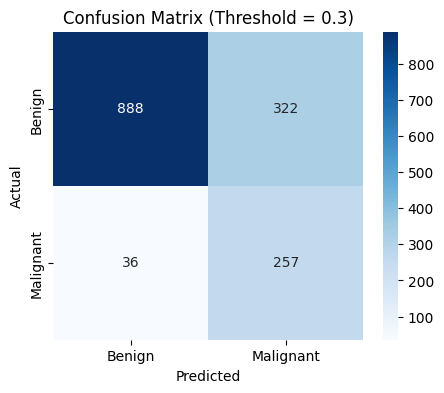

In [41]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

for threshold in thresholds:
    y_pred = (y_probs > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n========== Threshold = {threshold} ==========")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"], zero_division=0))

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()